In [1]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)-8s %(name)s: %(message)s",
    datefmt="%H:%M:%S",
)

import tanglepack
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
def henon_map(point):
    """
    Defines the henon map for binary horshoe parameters to test basic functionality
    """

    k, b = (10, 1)

    x = point[0]
    y = point[1]

    return np.array([y - k + x**2, -b * x])


def henon_map_inverse(point):
    """Defines the inverse henon map for"""

    k, b = (10, 1)

    x = point[0]
    y = point[1]

    return np.array([-y / b, x + k - (y**2) / (b**2)])

In [3]:
henon = tanglepack.DynamicalSystem(henon_map, henon_map_inverse)
fp_solver = tanglepack.FixedPointSolver(henon)
man_maker = tanglepack.ManifoldInitializer(henon)
man_machine = tanglepack.ManifoldMachine(henon)

tangle = tanglepack.Tangle()

# The registry is the single source of truth for resolved crossings: the Tangle
# detects segment pairs but keeps no Intersection of its own.
registry = tanglepack.IntersectionRegistry()

initial_guess = [4, -4]

# The period is read off the guess now; there is no second positional argument.
fixed_point = fp_solver.construct_fixed_point(initial_guess)

print(f"The fixed point is: {fixed_point.coordinates[0]}")

approx_dirs = {"unstable": np.array([-1, 0]), "stable": np.array([0, 1])}

man_maker.orient_manifolds(fixed_point, approx_dirs)

The fixed point is: [ 4.31662479 -4.31662479]


In [4]:
initial_stable_segment = man_maker.construct_kevin_way(fixed_point, "stable")

initial_unstable_segment = man_maker.construct_kevin_way(fixed_point, "unstable")

unstable_manifold = initial_unstable_segment[(0, 0)]
stable_manifold = initial_stable_segment[(0, 0)]

# grow unstable manifold
man_machine.grow_x_times(fixed_point, "unstable", 8)
unstable_manifold._find_tail()

# grow stable manifold
man_machine.grow_x_times(fixed_point, "stable", 9)
stable_manifold._find_tail()

In [5]:
"""detect the crossings and resolve them into the registry

`intersections_for_segment` / `populate_intersection_dict` / `_intersecting_coords`
are gone. `add_manifolds` bulk-loads every segment into the rtree in one stream and
records the crossing PAIRS; `resolve_crossings` turns each unstable x stable pair
into an `Intersection` (same-stability pairs are numerical artifacts and are
discarded), and the caller assigns the registry id.
"""

tangle.add_manifolds([unstable_manifold, stable_manifold])

for intersection in tangle.resolve_crossings():
    intersection.id = registry.add(intersection)

intersection_coords = [ix.coords for _id, ix in registry]

print(f"Intersections: {intersection_coords}")
print(f"Num intersections: {len(registry)}")

Intersections: [(np.float64(3.183648586892395), np.float64(4.045461227774294)), (np.float64(3.183448593115377), np.float64(-4.18135336563016)), (np.float64(-3.18351278238079), np.float64(-3.3187125345652455)), (np.float64(-3.1833946156779582), np.float64(3.1833946156779582)), (np.float64(-4.045461227774294), np.float64(-3.183648586892395)), (np.float64(1.5233074125460078), np.float64(3.839133533898783)), (np.float64(-1.794371613157379), np.float64(3.3898805248321193)), (np.float64(4.3166247903554), np.float64(-4.3166247903554))]
Num intersections: 8


(-15.0, 15.0)

04:48:36 WARNING  matplotlib.axes._base: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


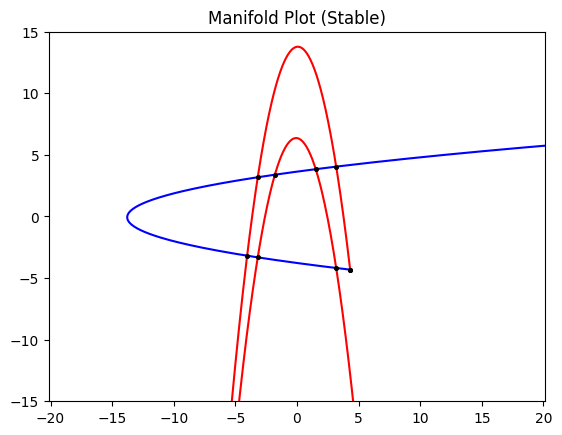

In [6]:
fig = plt.figure()

show_points = False
unstable_manifold.plot("blue", show_points=show_points)
stable_manifold.plot("red", show_points=show_points)
plt.scatter(*fixed_point.coordinates[0], c="k", s=7)

for point in intersection_coords:
    plt.scatter(*point, c="k", s=7, zorder=10)

plt.xlim([-15, 15])
plt.ylim([-15, 15])

In [7]:
"""cut the unstable manifold into bridges at the resolved crossings

The crossings to cut at are an INPUT to `create_bridges` now, and `cdist_tol` is
what stops two crossings at the same place on the curve from cutting a degenerate
zero-length bridge between them.
"""

bridges = tangle.create_bridges(
    [ix for _id, ix in registry], cdist_tol=registry.cdist_tol
)
print(f"Number of bridges: {len(bridges)}")
print(bridges)

Number of bridges: 7
[<tanglepack.numerics.Bridge.Bridge object at 0x7048c7fc3970>, <tanglepack.numerics.Bridge.Bridge object at 0x7048c5df21d0>, <tanglepack.numerics.Bridge.Bridge object at 0x7048c5df22c0>, <tanglepack.numerics.Bridge.Bridge object at 0x7048c5a01de0>, <tanglepack.numerics.Bridge.Bridge object at 0x7048c5a01cf0>, <tanglepack.numerics.Bridge.Bridge object at 0x7048c5a00400>, <tanglepack.numerics.Bridge.Bridge object at 0x7048c5bd8880>]


04:48:36 WARNING  matplotlib.axes._base: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


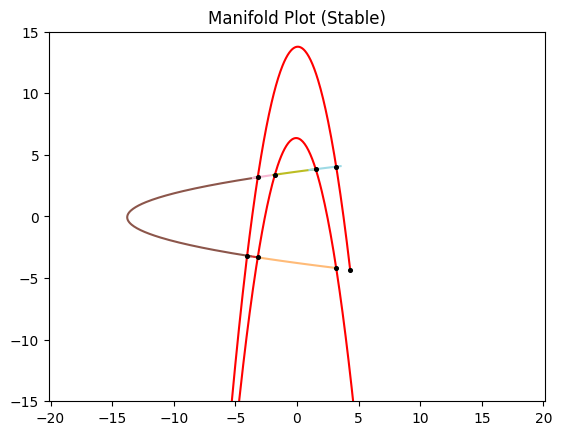

In [8]:
def plot_all_bridges(bridges):
    n = len(bridges)
    colors = plt.get_cmap("tab20").resampled(n)  # or 'tab10', 'nipy_spectral', etc.

    for i, bridge in enumerate(bridges):
        if i == 0:
            continue

        vibe = colors(i)
        bridge.plot(color=vibe)


fig = plt.figure()

plot_all_bridges(bridges)

stable_manifold.plot("red", show_points=show_points)

for point in intersection_coords:
    plt.scatter(*point, c="k", s=7, zorder=10)

plt.xlim([-15, 15])
plt.ylim([-15, 15])
plt.show()

In [9]:
new_manifold = man_machine.iterate_manifold(bridges[1])

04:48:36 WARNING  matplotlib.axes._base: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


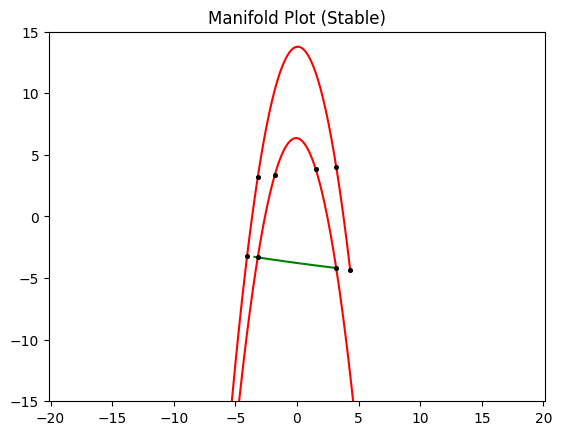

In [10]:
fig = plt.figure()

bridges[1].plot("green")
stable_manifold.plot("red", show_points=show_points)

for point in intersection_coords:
    plt.scatter(*point, c="k", s=7, zorder=10)

plt.xlim([-15, 15])
plt.ylim([-15, 15])
plt.show()

04:48:36 WARNING  matplotlib.axes._base: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


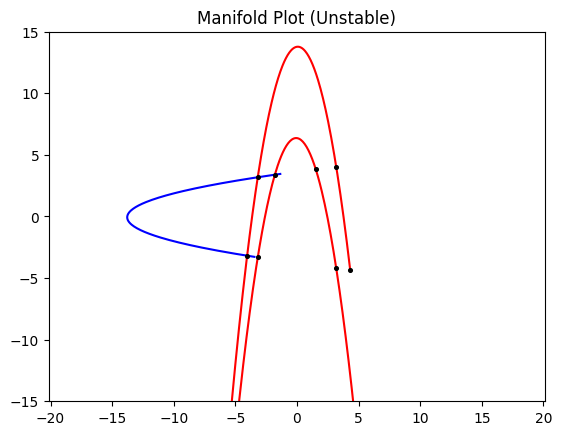

In [11]:
fig = plt.figure()

stable_manifold.plot("red", show_points=show_points)

for point in intersection_coords:
    plt.scatter(*point, c="k", s=7, zorder=10)

new_manifold.plot()

plt.xlim([-15, 15])
plt.ylim([-15, 15])
plt.show()

04:48:36 WARNING  matplotlib.axes._base: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


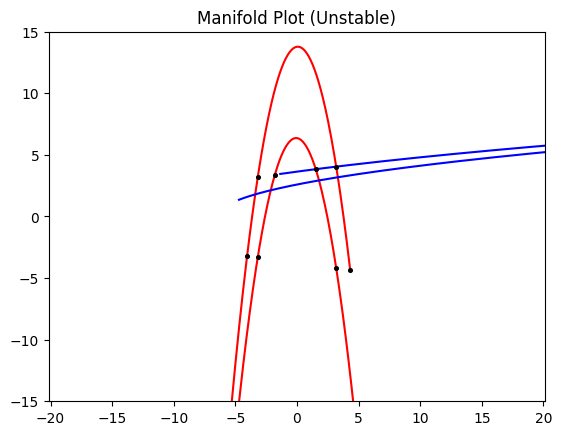

In [12]:
fig = plt.figure()

stable_manifold.plot("red", show_points=show_points)

new_manifold = man_machine.iterate_manifold(new_manifold)

for point in intersection_coords:
    plt.scatter(*point, c="k", s=7, zorder=10)

new_manifold.plot()

plt.xlim([-15, 15])
plt.ylim([-15, 15])
plt.show()